# Chirp missing-region reconstruction
Review committed results without raw HDF5 files. The optional final cell reruns the benchmark when the local recordings are available.

**Scope:** known masks, controlled degradation, training/validation/test rows within each recording. The raster experiment reads actual pixels of a calibrated blue-trace image. It is not an arbitrary biomedical screenshot reader. Best/median/worst examples are selected retrospectively for presentation; restoration methods are selected on validation rows.

In [1]:
from pathlib import Path
import json
import sys
import subprocess
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = ROOT / 'outputs/chirp/gap_reconstruction'
summary = pd.read_csv(RESULTS / 'selected_test_summary.csv')
display(summary.round(3))


,source,profile,selected_method,test_traces,zero_gap_rmse,linear_gap_rmse,selected_gap_rmse,mean_gap_rmse_reduction_percent,fraction_better_than_zero,median_per_trace_reduction_percent,worst_per_trace_reduction_percent
0,chirp_9db,short_gaps,local_pca_32,36,3.902,4.743,1.847,52.652,0.917,53.644,-30.692
1,chirp_9db,long_gaps,autoregression,36,2.457,2.474,2.454,0.123,0.639,0.061,-0.451
2,chirp_9db,mixed_damage,local_pca_32,36,3.135,3.190,2.735,12.780,0.722,11.388,-28.801
3,chirp_9db,severe_4x,local_pca_8,36,3.135,3.147,2.669,14.879,0.806,14.006,-32.417
4,chirp_9db,raster_image,local_pca_32,36,3.902,4.572,1.938,50.324,0.917,51.907,-30.670
5,am_9db,short_gaps,local_pca_32,36,4.485,4.823,3.547,20.916,0.722,27.964,-45.056
6,am_9db,long_gaps,zero_fill,36,2.495,2.524,2.495,0.000,0.000,0.000,0.000
7,am_9db,mixed_damage,autoregression,36,3.274,3.279,3.267,0.198,0.583,0.048,-0.976
8,am_9db,severe_4x,zero_fill,36,3.274,3.277,3.274,0.000,0.000,0.000,0.000
9,am_9db,raster_image,local_pca_32,36,4.485,4.770,3.588,19.998,0.722,25.325,-45.556


## What counts as improvement?
`gap_rmse` measures error only in erased samples. `zero_gap_rmse` is the error when a missing segment is left at zero. Lower selected gap RMSE is better. A positive mean reduction does not imply that every trace improves. Inspect the fraction improved and the worst example too.

best row 18570 gap-error reduction: 82.9 %


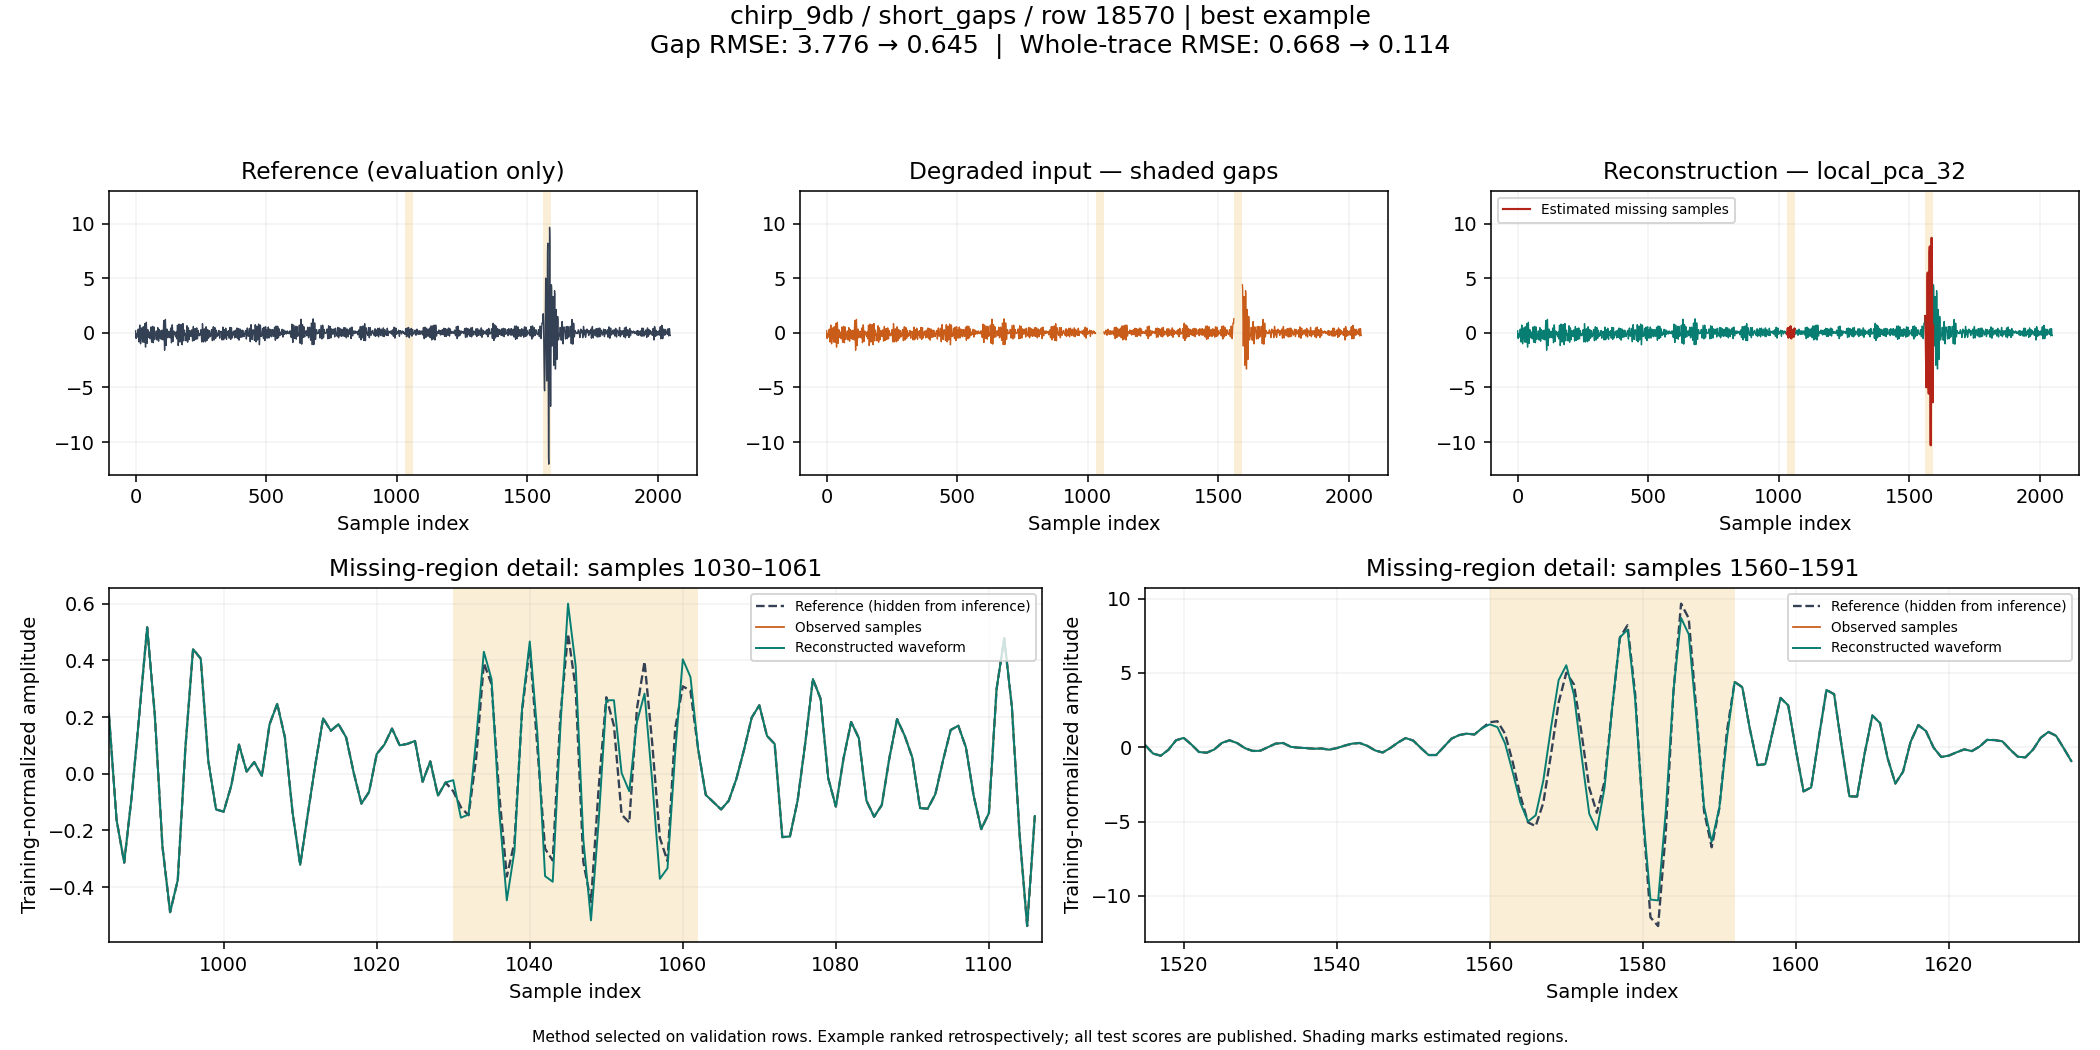

median row 19599 gap-error reduction: 53.8 %


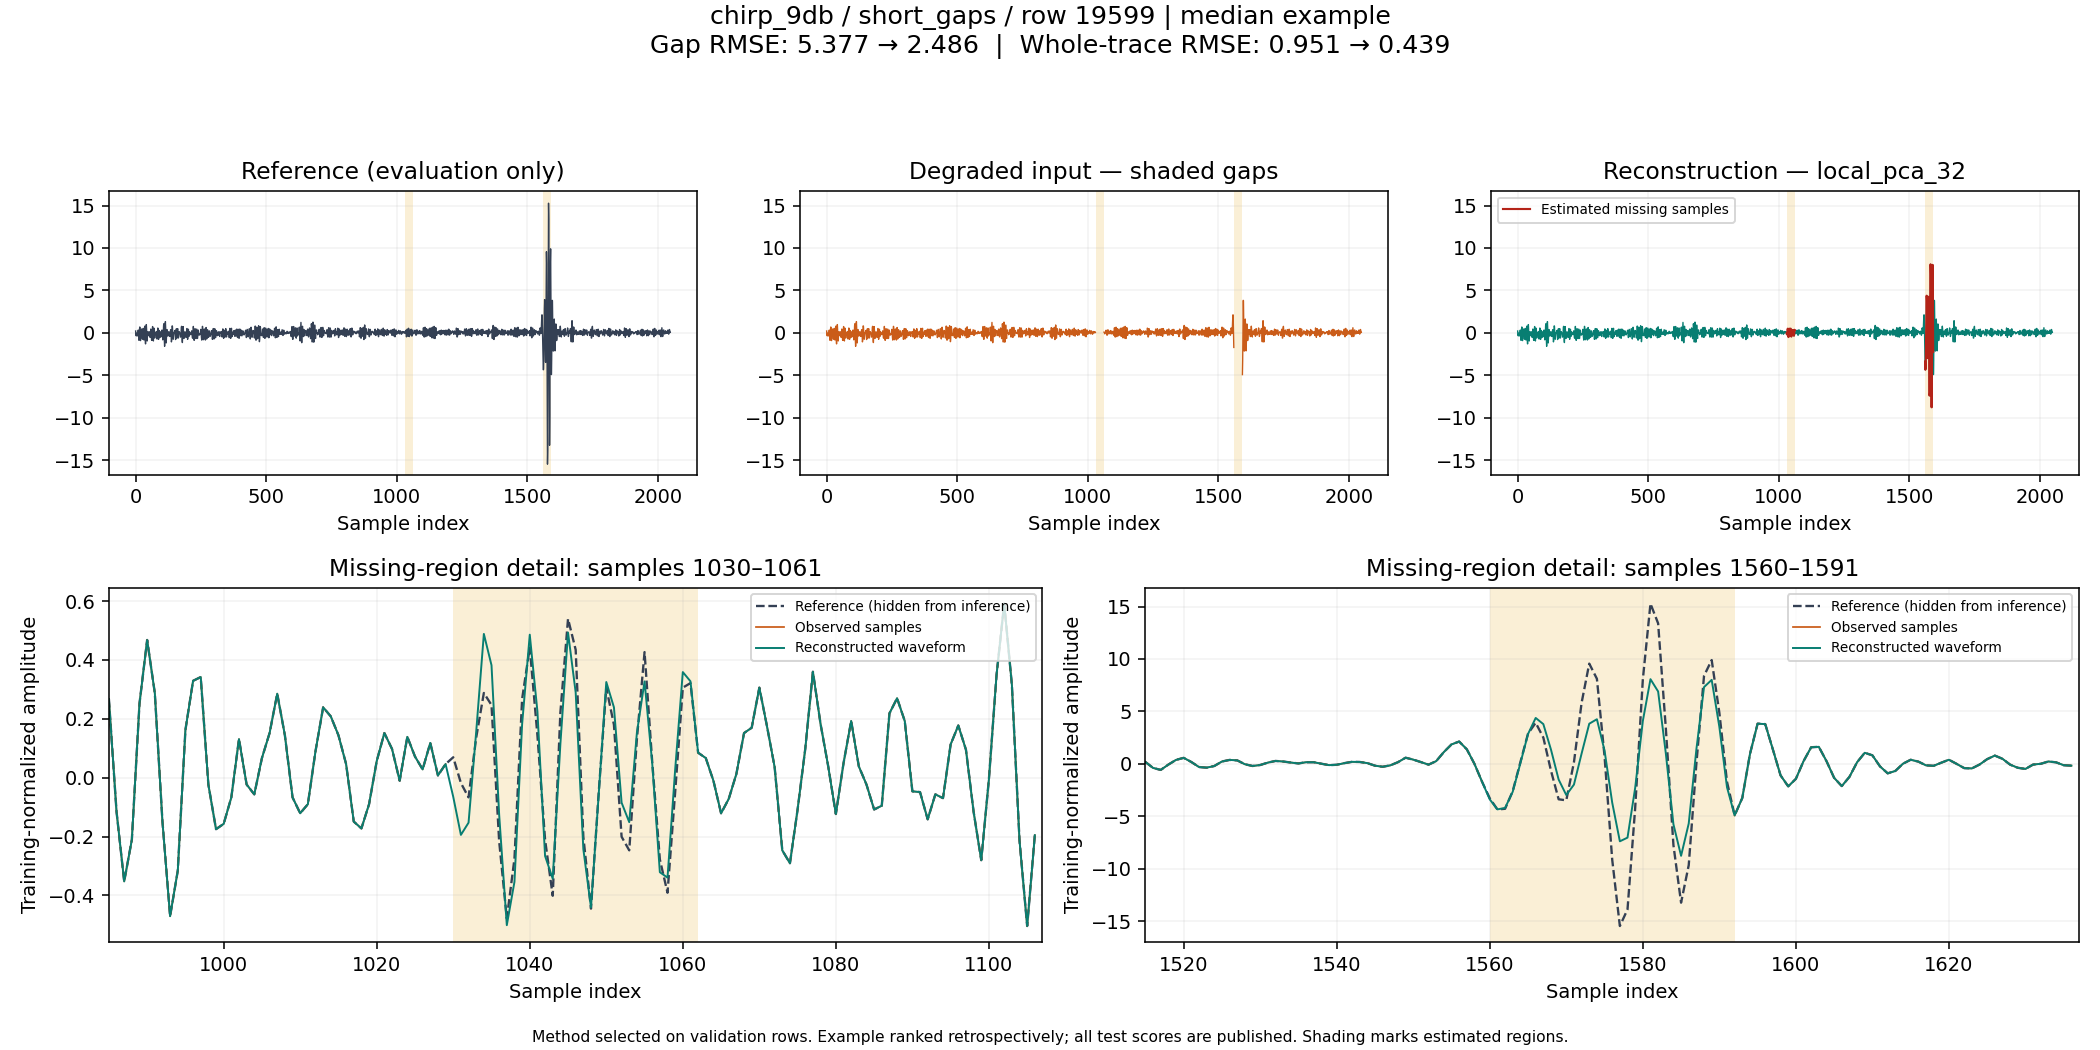

worst row 16822 gap-error reduction: -30.7 %


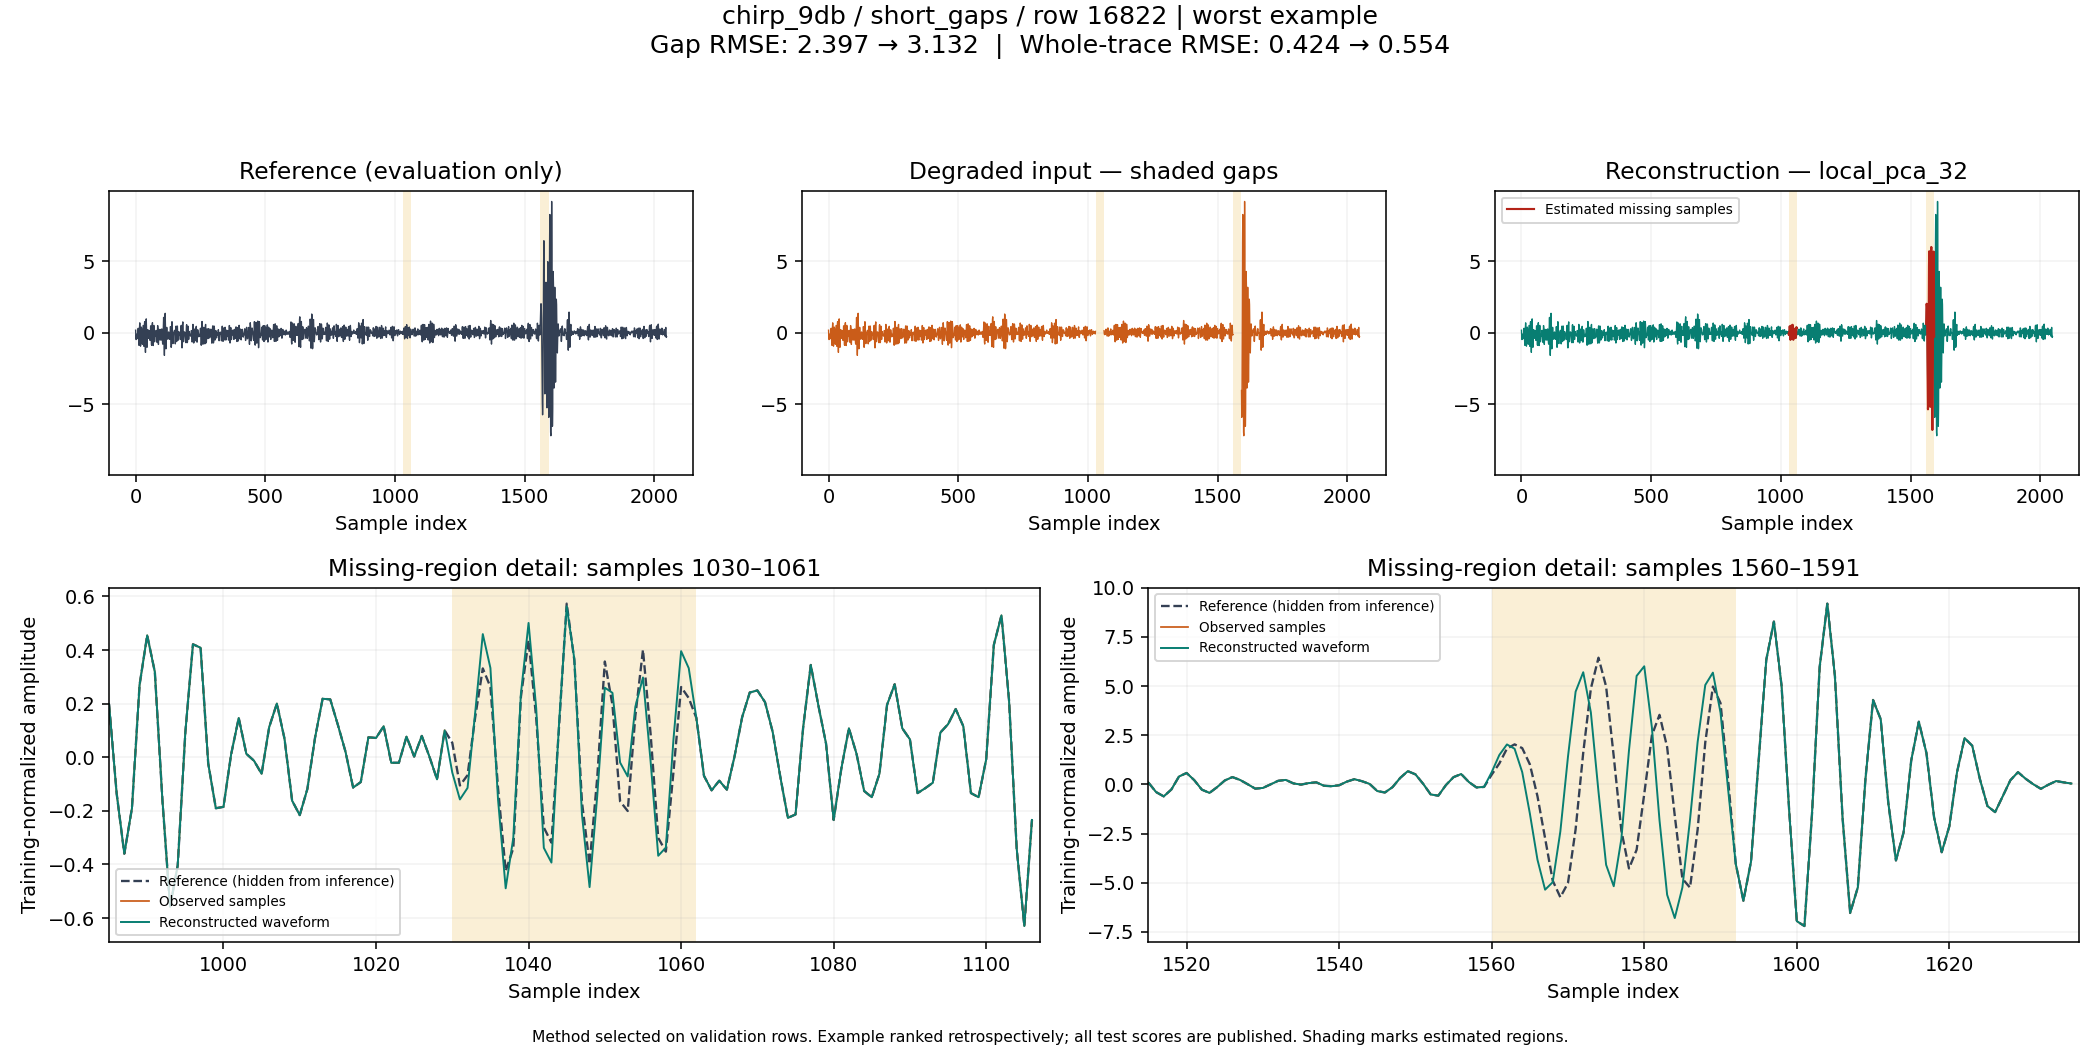

In [2]:
gallery = pd.read_csv(RESULTS / 'gallery.csv')
examples = gallery[(gallery.source == 'chirp_9db') & (gallery.profile == 'short_gaps')]
for example in examples.itertuples():
    print(example.role, 'row', example.row, 'gap-error reduction:', round(example.reduction_percent, 1), '%')
    display(Image(filename=str(RESULTS / example.image), width=1000))


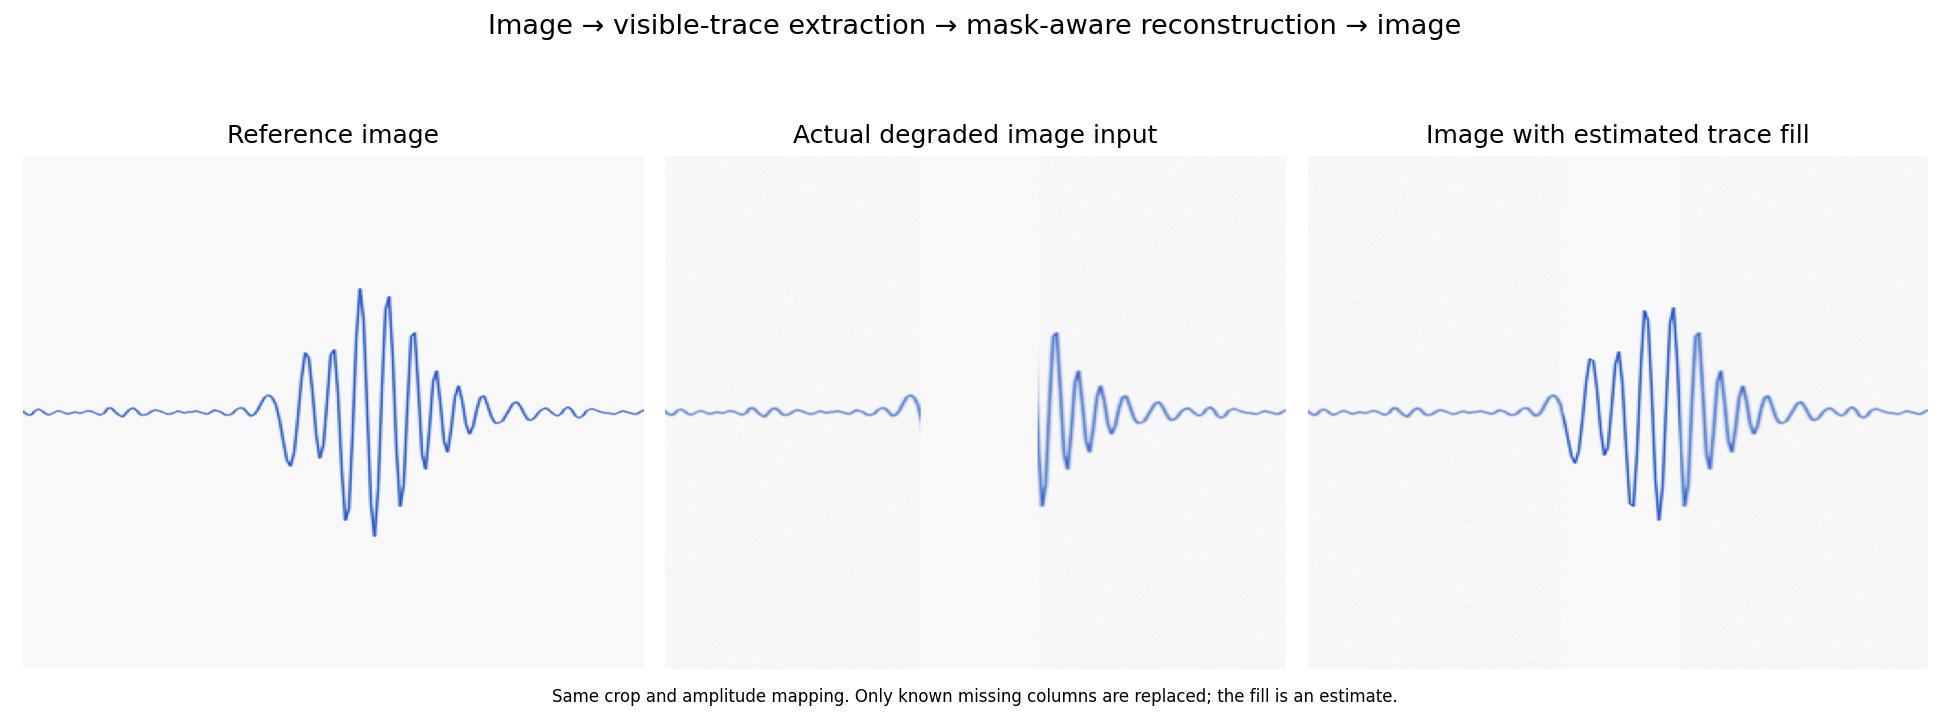

The original image, degraded image, and enhanced PNG are saved beside this panel.


In [3]:
image_example = gallery[(gallery.source == 'chirp_9db') & (gallery.profile == 'raster_image') & (gallery.role == 'best')].iloc[0]
image_path = (RESULTS / image_example.image).parent / 'image_before_after.png'
display(Image(filename=str(image_path), width=1000))
print('The original image, degraded image, and enhanced PNG are saved beside this panel.')


In [4]:
manifest = json.loads((RESULTS / 'manifest.json').read_text())
for source, details in manifest['sources'].items():
    train, validation, test = map(set, (details['training_rows'], details['validation_rows'], details['test_rows']))
    assert not (train & validation or train & test or validation & test)
    print(source, 'training:', len(train), 'validation:', len(validation), 'test:', len(test))
print('Disjoint row splits checked. These are not independent subject/recording splits.')


chirp_9db training: 1800 validation: 24 test: 36
am_9db training: 1800 validation: 24 test: 36
v3 training: 1800 validation: 24 test: 36
Disjoint row splits checked. These are not independent subject/recording splits.


## Optional full rerun
Install `requirements-gap.txt` first. Set the folder containing the three HDF5 files below, then change `RERUN` to `True`. This performs real fitting, validation, evaluation and figure generation on CPU. Original recordings are not modified. The command writes a fresh local result folder.

In [5]:
RERUN = False
DATA_ROOT = Path(r'C:\Users\DELL\Desktop\hs lit theiory\Chirp data')
if RERUN:
    destination = ROOT / 'outputs/chirp/local_gap_rerun'
    subprocess.run([sys.executable, str(ROOT / 'run_chirp_gap_benchmark.py'), '--data-root', str(DATA_ROOT), '--output', str(destination)], cwd=ROOT, check=True)
    subprocess.run([sys.executable, str(ROOT / 'render_chirp_gap_report.py'), '--input', str(destination)], cwd=ROOT, check=True)
else:
    print('Browsing committed evidence; no training or data download was performed.')


Browsing committed evidence; no training or data download was performed.
